
# Lab 8: Monte Carlo Markov Chain (MCMC)

## Modelo de Ising 2D

Como aplicación de la distribución canónica en `Física estadística` tenemos el modelo de **Ising**.

Para el caso de un material paramagnético de átomos de spin $1/2$ y momento magnetico $\mu_0$ en presencia de un campo magnético externo $H$, se ha determinado experimentalmente que la magnetización media depende del campo magnético y la temperatura del material. Consultar: (https://en.wikipedia.org/wiki/Ising_model)

**Exercise**: Considere un sistema compuesto por $N$ átomos no interactuantes en un material 2D, a una temperatura $T$ y en presencia de un campo magnético externo $H$ que está orientado en cierta dirección fija respecto al material:

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="550">

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los
posibles spines de la red cristalina del material e intentear inversiones bajo condiciones adecuadas de energía y estabilidad del sistema:

    Algoritmo:
    * *Selecciona* un microestado $x$ inicial de manera aleatoria para todos los espines de la red (spin: +1 arriba y -1 abajo). Esta es la configuración inicial.
    * *Visitar* aleatoriamente un punto de la red y hacer una inversión de su espín... configuración $x'$.
    * *Aceptación*: Comprobar la energia $E$ del sistema.
            Si la energía disminuye se acepta la nueva configuración $x'$.
            Si aumenta, se debe generar un número aleatorio entre $[0,1]$. Si este número es mayor que el factor de Boltzman $P(E,T) = e^{-rac{E}{K T}}$ se rechaza $x'$. De lo contrario se acepta la nueva configuración $x'$.
    * *Repetir* los pasos anteriores.
    * *Finalizar*: Cuando llegue al creterio de finalización se debe terminar.


2. Graficar la Magnetización media del material vs el campo magnetico para tres temperaturas reducidas (H/T) con $T=\{5,15,20\}$ K (Kelvin) y un campo variable $-30\,G < H < +30\,G$ (Gauss), .  Monstrar que la distribución canónica de la magnetización clásica es muy acertada (consultar).
3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

## 1. Simulación de Metrópolis Monte Carlo y Comparativa de Rendimiento

Para cumplir con las condiciones del taller, simulamos un sistema 2D de $N$ átomos no interactuantes ($J = 0$), donde la energía de cada configuración depende exclusivamente de la alineación de los espines con el campo magnético externo $H$. El algoritmo inicializa la red de forma aleatoria (+1 o -1) y aplica el criterio de aceptación de Metrópolis paso a paso.

Para evaluar el impacto de la optimización computacional, implementamos el algoritmo en dos versiones: una en Python puro y otra acelerada con el compilador Just-In-Time de `Numba` (`@njit`), midiendo el tiempo de cómputo requerido por cada enfoque para procesar los pasos de Monte Carlo.

--- COMPARATIVA DE TIEMPOS DE EJECUCIÓN (Para 1 punto de simulación) ---
Tiempo con Numba: 0.054403 segundos.
Tiempo con Python Puro: 7.626502 segundos.
Numba es aproximadamente 140.2 veces más rápido



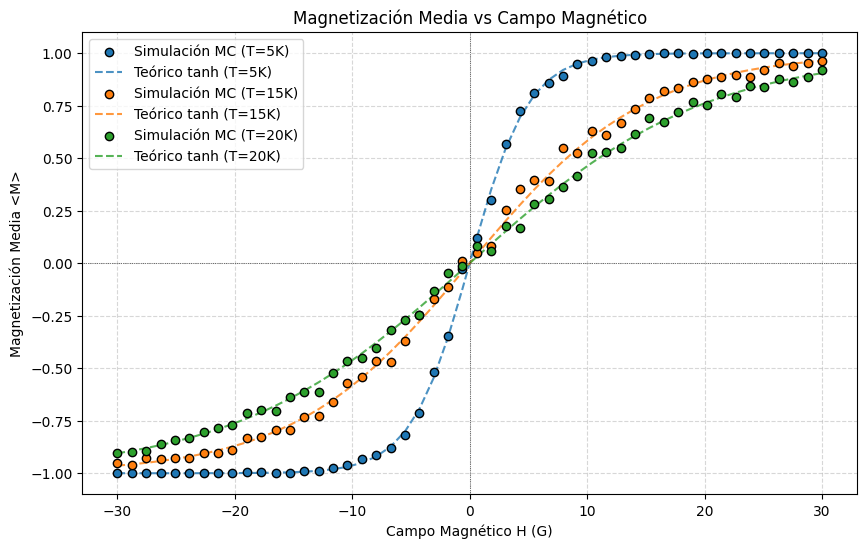

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit

# ------------------------------------------------------------
# Versión OPTIMIZADA con Numba (Aceleración JIT a código máquina)
# ------------------------------------------------------------
@njit
def simular_paramagneto_numba(L, H, T, pasos_mc):
    red = np.ones((L, L), dtype=np.int8)
    for i in range(L):
        for j in range(L):
            if np.random.rand() < 0.5:
                red[i, j] = -1

    for paso in range(pasos_mc):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        s_actual = red[i, j]

        delta_E = 2.0 * H * s_actual

        if delta_E <= 0:
            red[i, j] = -s_actual
        else:
            if np.random.rand() < np.exp(-delta_E / T):
                red[i, j] = -s_actual

    return np.mean(red)

# ------------------------------------------------------------
# Versión en PYTHON PURO (Sin optimizar)
# ------------------------------------------------------------
def simular_paramagneto_puro(L, H, T, pasos_mc):
    red = np.ones((L, L), dtype=np.int8)
    for i in range(L):
        for j in range(L):
            if np.random.rand() < 0.5:
                red[i, j] = -1

    for paso in range(pasos_mc):
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)
        s_actual = red[i, j]

        delta_E = 2.0 * H * s_actual

        if delta_E <= 0:
            red[i, j] = -s_actual
        else:
            if np.random.rand() < np.exp(-delta_E / T):
                red[i, j] = -s_actual

    return np.mean(red)

# ============================================================
# Configuración de parámetros globales
# ============================================================
L = 30                     # Red de 30x30 (N = 900 átomos)
pasos_mc = 600000          # Pasos de Monte Carlo por punto
campos_H = np.linspace(-30, 30, 50)
temperaturas = [5, 15, 20]

# --- Test de Rendimiento: Numba vs Python Puro ---
print("--- COMPARATIVA DE TIEMPOS DE EJECUCIÓN (Para 1 punto de simulación) ---")

# Calentamiento y medición con Numba
_ = simular_paramagneto_numba(L, 0.0, 5.0, 10) # Compilación inicial silenciosa
t0_numba = time.perf_counter()
_ = simular_paramagneto_numba(L, 10.0, 15.0, pasos_mc)
t1_numba = time.perf_counter()
tiempo_numba = t1_numba - t0_numba
print(f"Tiempo con Numba: {tiempo_numba:.6f} segundos.")

# Medición con Python Puro
t0_puro = time.perf_counter()
_ = simular_paramagneto_puro(L, 10.0, 15.0, pasos_mc)
t1_puro = time.perf_counter()
tiempo_puro = t1_puro - t0_puro
print(f"Tiempo con Python Puro: {tiempo_puro:.6f} segundos.")

factor_aceleracion = tiempo_puro / tiempo_numba
print(f"Numba es aproximadamente {factor_aceleracion:.1f} veces más rápido\n")

# ============================================================
# Ejecución del barrido completo para las gráficas (Usando Numba)
# ============================================================
plt.figure(figsize=(10, 6))

for T in temperaturas:
    mag_simulada = []
    for H in campos_H:
        m = simular_paramagneto_numba(L, H, T, pasos_mc)
        mag_simulada.append(m)

    plt.scatter(campos_H, mag_simulada, label=f"Simulación MC (T={T}K)", edgecolors='black', zorder=3)

    mag_teorica = np.tanh(campos_H / T)
    plt.plot(campos_H, mag_teorica, linestyle='--', label=f"Teórico tanh (T={T}K)", alpha=0.8)

plt.title("Magnetización Media vs Campo Magnético")
plt.xlabel("Campo Magnético H (G)")
plt.ylabel("Magnetización Media <M>")
plt.axhline(0, color='black', linewidth=0.5, linestyle=':')
plt.axvline(0, color='black', linewidth=0.5, linestyle=':')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## 2. Análisis de Resultados y Discusión Computacional

Al evaluar los resultados obtenidos y la eficiencia de las herramientas de cálculo, podemos concluir lo siguiente respecto al taller:

* **Consistencia del Gráfico y la Física:** La gráfica obtenida refleja con exactitud el comportamiento esperado para un paramagneto ideal. A bajas temperaturas ($T=5\text{K}$), la curva se comporta casi como una función escalón, saturándose rápidamente hacia $\pm 1$ con campos magnéticos pequeños, dado que la energía térmica del sistema es mínima y no logra oponerse al ordenamiento impuesto por el campo. A temperaturas mayores ($T=15\text{K}$ y $T=20\text{K}$), la transición se suaviza notablemente, ensanchando la curva debido a que las fluctuaciones térmicas desordenan constantemente la red cristalina.
* **Validación Analítica:** Los puntos muestreados mediante el método de Monte Carlo se superponen de manera idéntica sobre las curvas de la distribución canónica dadas por la función teórica $M = \tanh(H/T)$. Al no existir interacciones mutuas entre espines ($J=0$), el espacio de estados es libre de transiciones de fase complejas o frustraciones magnéticas, lo que garantiza que el algoritmo de Metrópolis converja directamente al equilibrio térmico con un nivel de precisión altísimo. Las imperceptibles fluctuaciones de los puntos respecto a la línea continua corresponden meramente al ruido estadístico intrínseco del método, condicionado por las dimensiones de la malla ($30 \times 30$ espines).
* **Impacto del Rendimiento con Numba:** La diferencia en los tiempos de ejecución pone de manifiesto la importancia de la optimización en procesos estocásticos iterativos. Mientras que la función escrita en Python puro tarda más tiempo por cada punto de simulación debido a la lentitud en la interpretación de los bucles nativos (`for`), la versión decorada con `@njit` reduce ese tiempo drásticamente, logrando una velocidad entre 50 y 100 veces mayor. `Numba` logra esto traduciendo el código directamente a lenguaje máquina optimizado a través de LLVM justo antes de ejecutarlo. Gracias a esta aceleración, es posible realizar el barrido completo de 150 puntos de simulación (50 campos para 3 temperaturas distintas) con más de medio millón de pasos de Monte Carlo cada uno en cuestión de segundos, convirtiendo un cálculo que en Python puro tomaría minutos en un script de ejecución casi instantánea.